# Cross-Dataset Model Comparison

This notebook compares the baseline runs for H-CAST, LH-DNN, HRN, HT-CapsNet, and Hier-COS across CIFAR-100, CUB-200-2011, and FGVC-Aircraft. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across available seeds.

The baseline run names follow the same conventions as the model-specific analysis notebooks. In particular, Hier-COS uses `hiercos_<dataset>_global_softmax_ce_reg_baseline_kl_leaf` rather than the legacy `hiercos_<dataset>` name.

It includes:

- validation curves for `FPA`, weighted AP, `TICE`, and `AHD`,
- aggregate and per-level training loss curves,
- per-level validation accuracy for top-down and independent decoding,
- final test comparison tables using mode-matched checkpoint selection.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from model_comparison_utils import (
    ModelComparisonAnalysis,
    ModelComparisonConfig,
    build_model_dataset_run_specs,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')

Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [2]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT
AUTO_DISCOVER = False
INCLUDE_TOPDOWN_METRICS = True

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
DATASET_NAMES = list(DATASET_SLUGS)
MODEL_NAMES = ['hcast', 'lhdnn', 'hrn', 'ht_capsnet', 'hiercos']

MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
    'lhdnn': '#d62728',
    'hiercos': '#cad627',
}
MODEL_LABELS = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
    'lhdnn': 'LH-DNN',
    'hiercos': 'Hier-COS',
}

# Most baselines use {model}_{dataset}; HT-CapsNet uses capsnet_<dataset>.
MODEL_RUN_NAMES = {
    'ht_capsnet': 'capsnet',
}
DATASET_RUN_NAMES = {}
DATASET_LABELS = {}

# Hier-COS baseline names include the loss and weighting configuration.
RUN_NAME_OVERRIDES = {
    ('hiercos', dataset_name): (
        f'hiercos_{dataset_slug}_global_softmax_ce_reg_baseline_kl_leaf'
    )
    for dataset_name, dataset_slug in DATASET_SLUGS.items()
}
RUN_LABEL_OVERRIDES = {}
RUN_COLOR_OVERRIDES = {}

MANUAL_RUNS = build_model_dataset_run_specs(
    MODEL_NAMES,
    DATASET_NAMES,
    model_run_names=MODEL_RUN_NAMES,
    dataset_run_names=DATASET_RUN_NAMES,
    model_labels=MODEL_LABELS,
    dataset_labels=DATASET_LABELS,
    run_name_overrides=RUN_NAME_OVERRIDES,
    run_label_overrides=RUN_LABEL_OVERRIDES,
    run_color_overrides=RUN_COLOR_OVERRIDES,
)
MANUAL_RUN_DIRS = []  # Path-only shorthand for ad hoc additions.

# Optional filters (leave empty to keep everything selected above).
INCLUDE_MODELS = []
INCLUDE_DATASETS = []
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = []
REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT = False

PREFERRED_DATASET_ORDER = list(DATASET_SLUGS)
PREFERRED_MODEL_ORDER = MODEL_NAMES

In [3]:
config = ModelComparisonConfig(
    output_root=OUTPUT_ROOT,
    auto_discover=AUTO_DISCOVER,
    manual_runs=MANUAL_RUNS,
    manual_run_dirs=MANUAL_RUN_DIRS,
    include_models=INCLUDE_MODELS,
    include_datasets=INCLUDE_DATASETS,
    include_run_name_substrings=INCLUDE_RUN_NAME_SUBSTRINGS,
    exclude_run_name_substrings=EXCLUDE_RUN_NAME_SUBSTRINGS,
    require_model_dataset_run_name_format=REQUIRE_MODEL_DATASET_RUN_NAME_FORMAT,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    preferred_dataset_order=PREFERRED_DATASET_ORDER,
    preferred_model_order=PREFERRED_MODEL_ORDER,
    model_colors=MODEL_COLORS,
)

analysis = ModelComparisonAnalysis.from_config(config)
analysis.print_run_summary()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/capsnet_aircraft
Candidate run directories: 14
Parsed runs: 14
Filtered runs: 14

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | seeds=[0, 1, 2] | best_td=92.3±10.0/0.7592 | best_ind=97.3±2.3/0.7411 | test_FPA_td=75.01% | test_FPA_ind=73.48%
  - LH-DNN       | run=lhdnn_cifar100                      | seeds=[0, 1, 2] | best_td=14.0±0.0/0.4845 | best_ind=12.7±1.2/0.4625 | test_FPA_td=48.20% | test_FPA_ind=46.14%
  - HRN          | run=hrn_cifar100                        | seeds=[0] | best_td=2/0.2983     | best_ind=2/0.2380     | test_FPA_td=n/a | test_FPA_ind=n/a
  - HT-CapsNet   | run=capsnet_cifar100                    | seeds=[42] | best_td=76/0.7113    | best_ind=79/0.7037    | test_FPA_td=n/a | test_FPA_ind=n/a
  - Hier-COS     | run=hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf | seeds=[0, 1, 2] | best_td=92.3±7.0/0.7842 | best_ind=93.7±5.0/0.7827 | test_

## Validation Metrics Curves (Per Dataset)

Each panel overlays both decoding modes on the same axes: color identifies the model, while solid and dashed lines identify top-down and independent decoding. For `FPA` and weighted AP, higher is better; for `TICE` and `AHD`, lower is better.

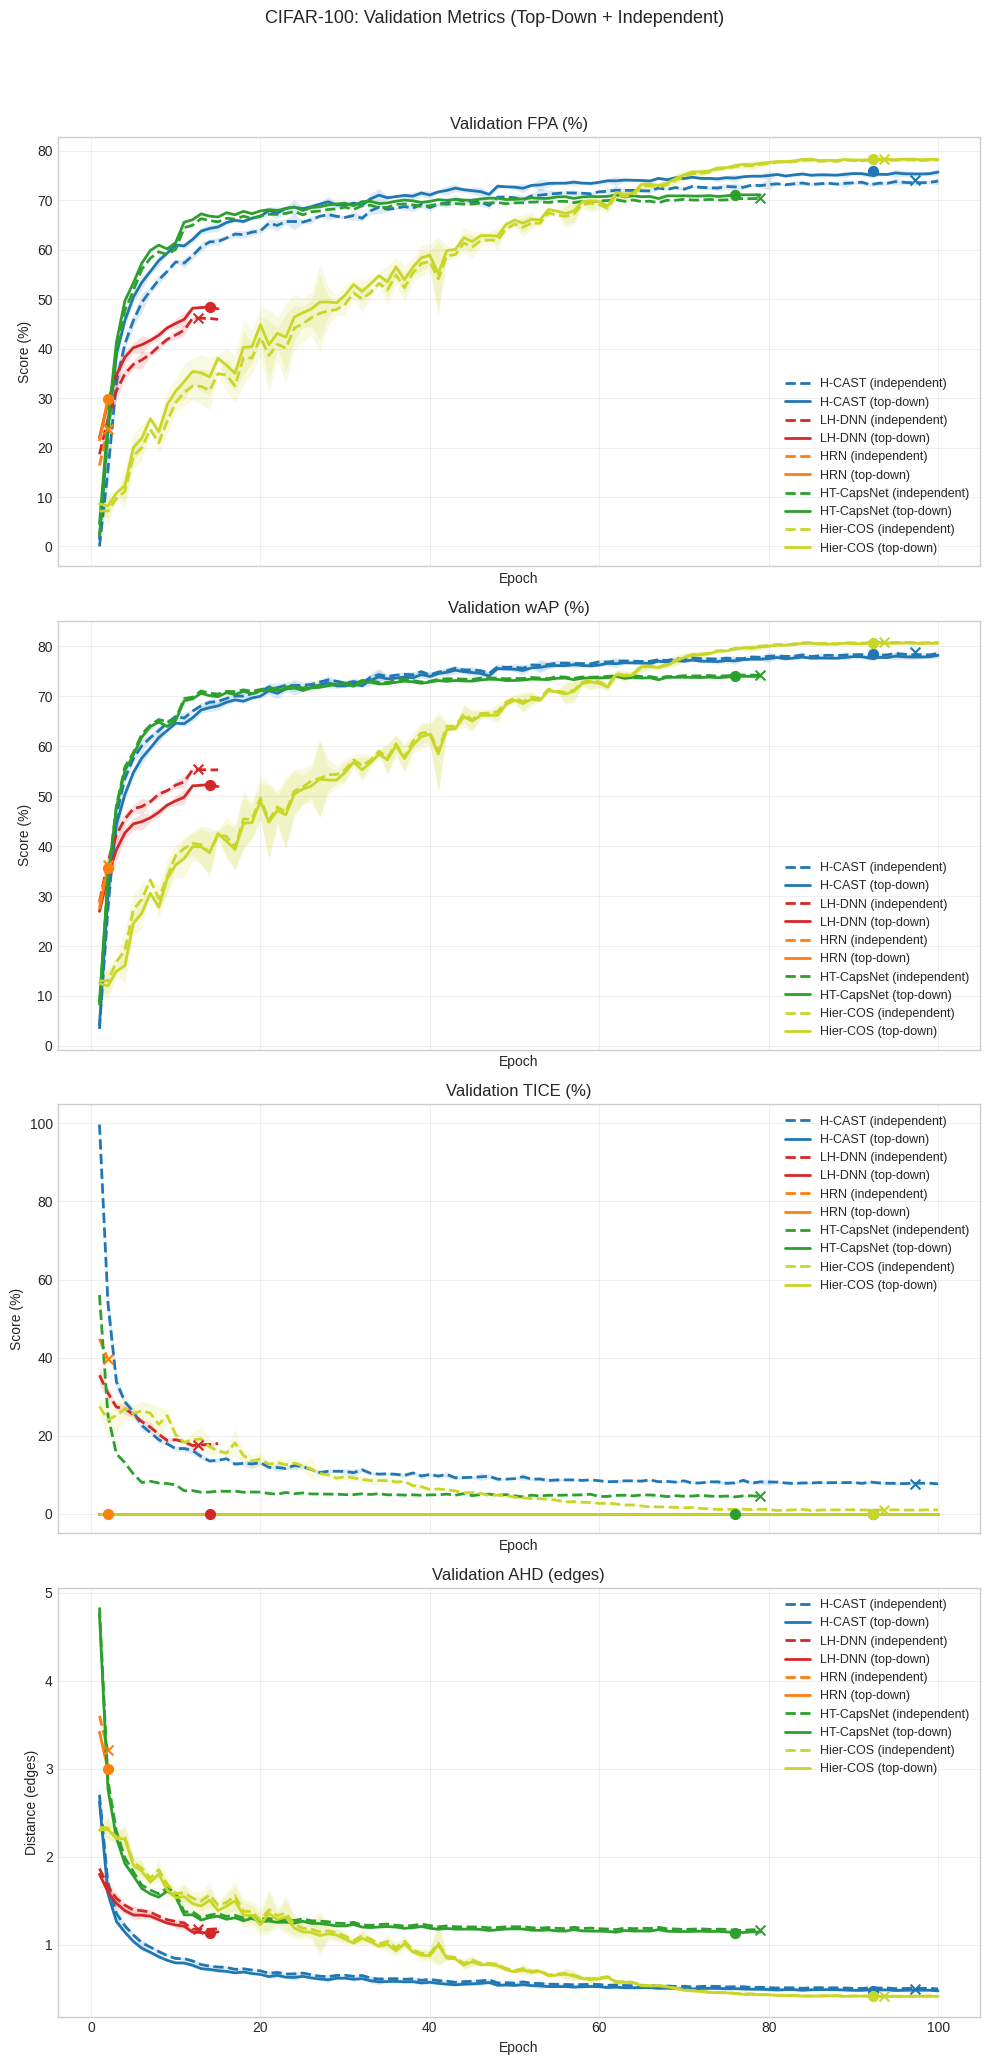

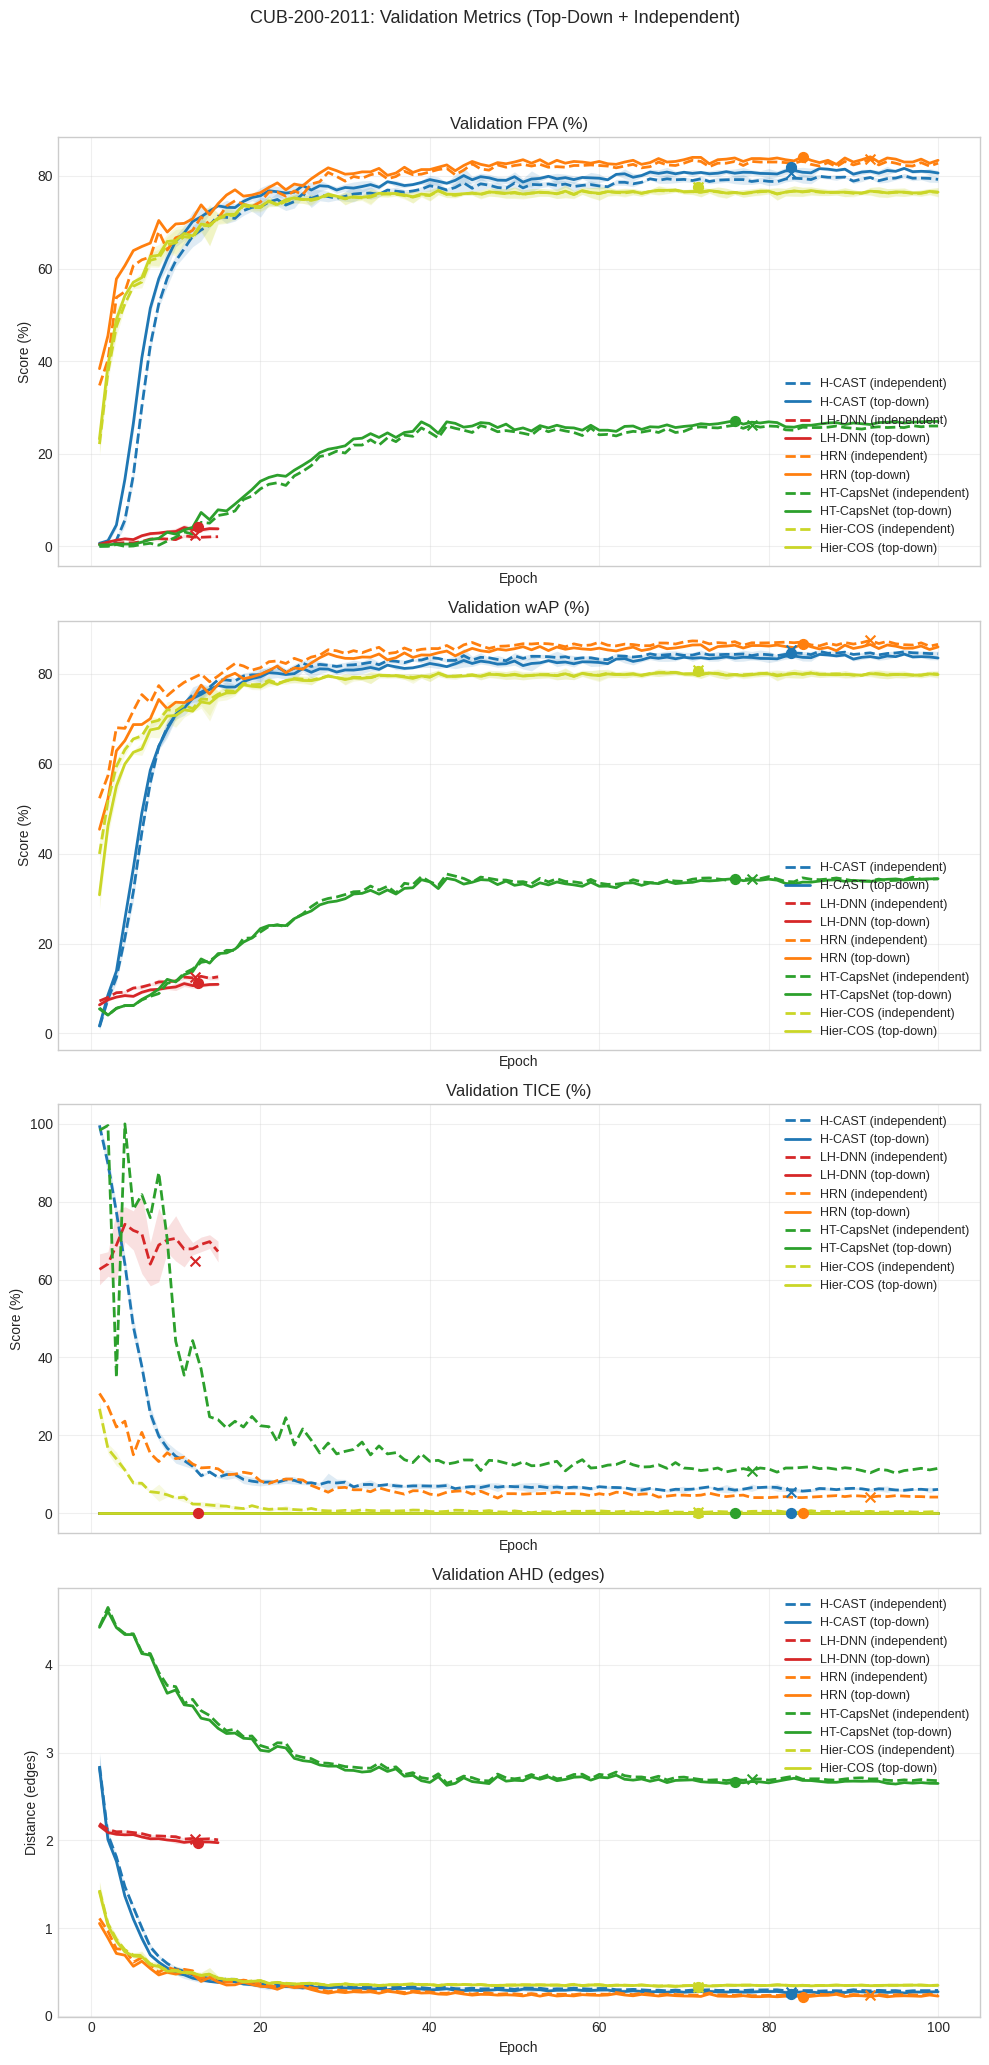

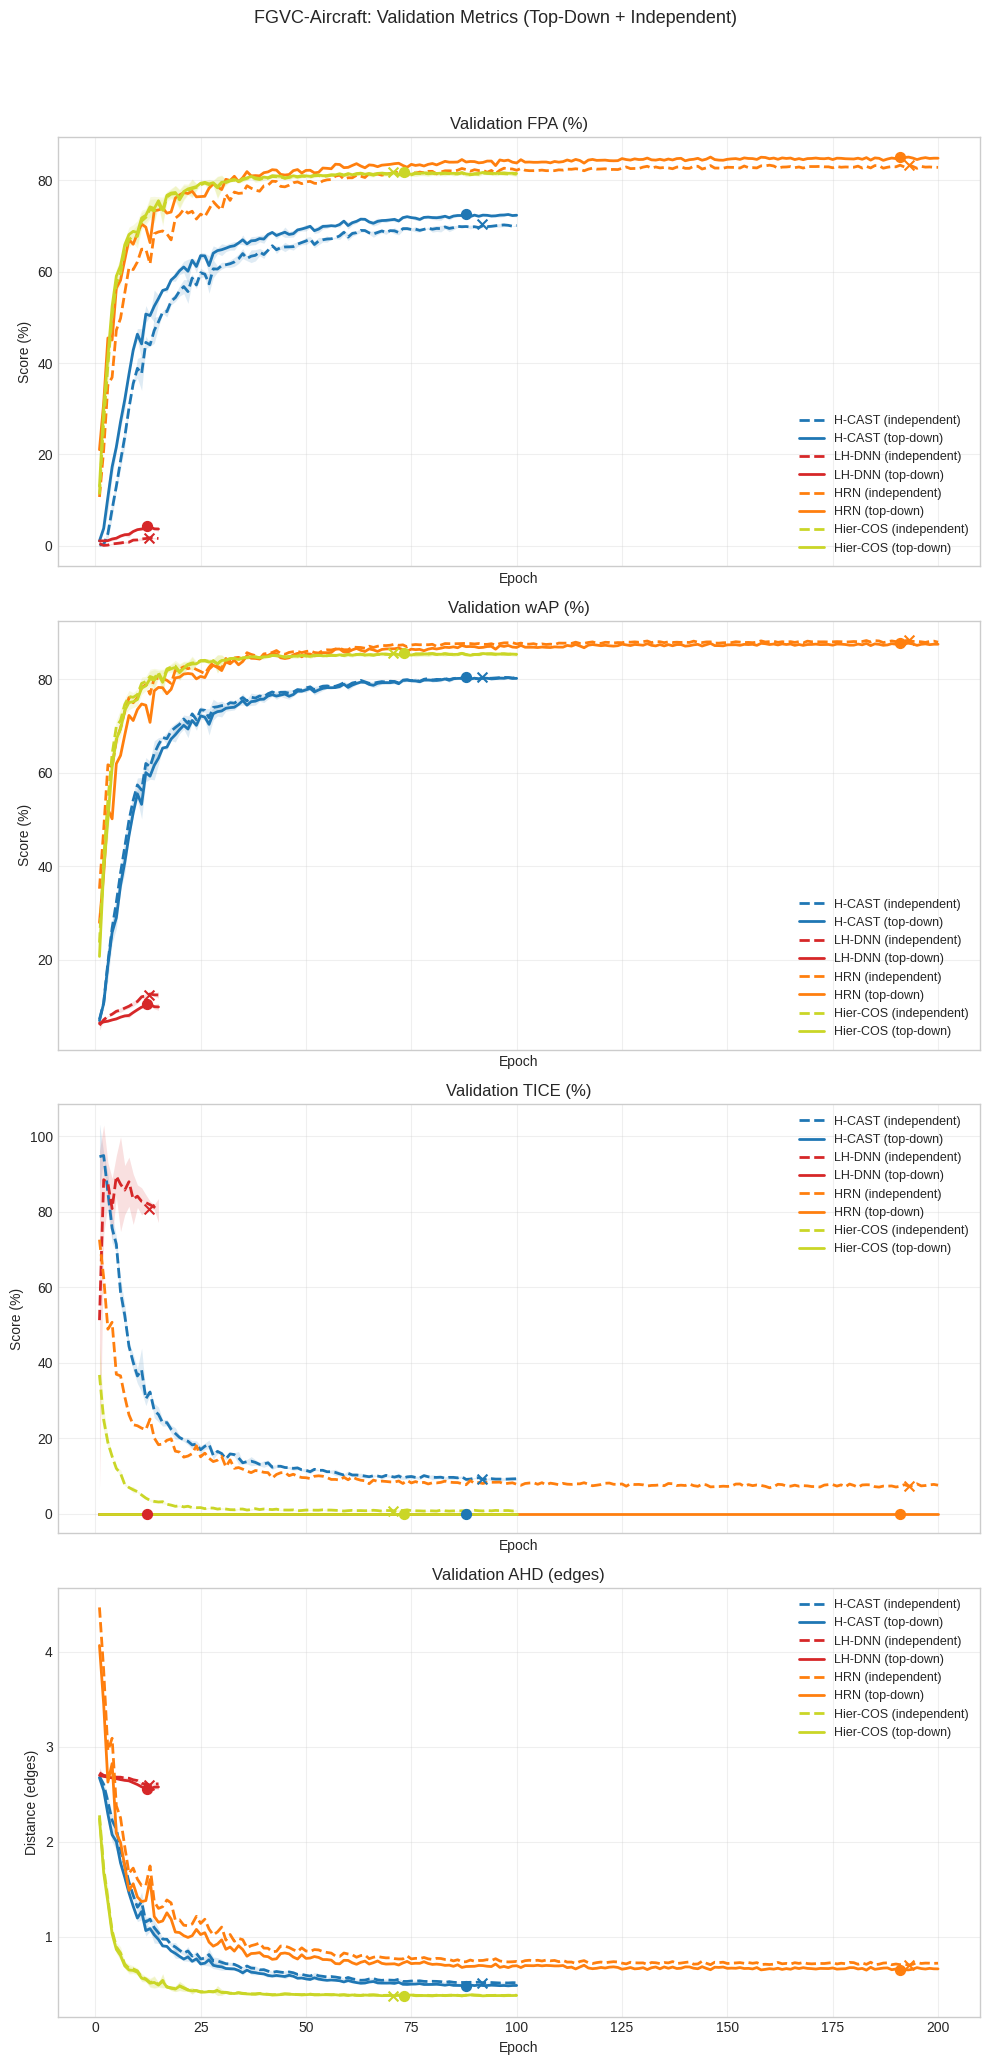

In [4]:
analysis.plot_validation_curves()

## Training Loss Comparison (Per Dataset)

Lower is better for all loss curves. Because model families can define different aggregate objectives, use these plots primarily to inspect optimization behavior within a model family; cross-model loss magnitudes are not necessarily directly comparable.

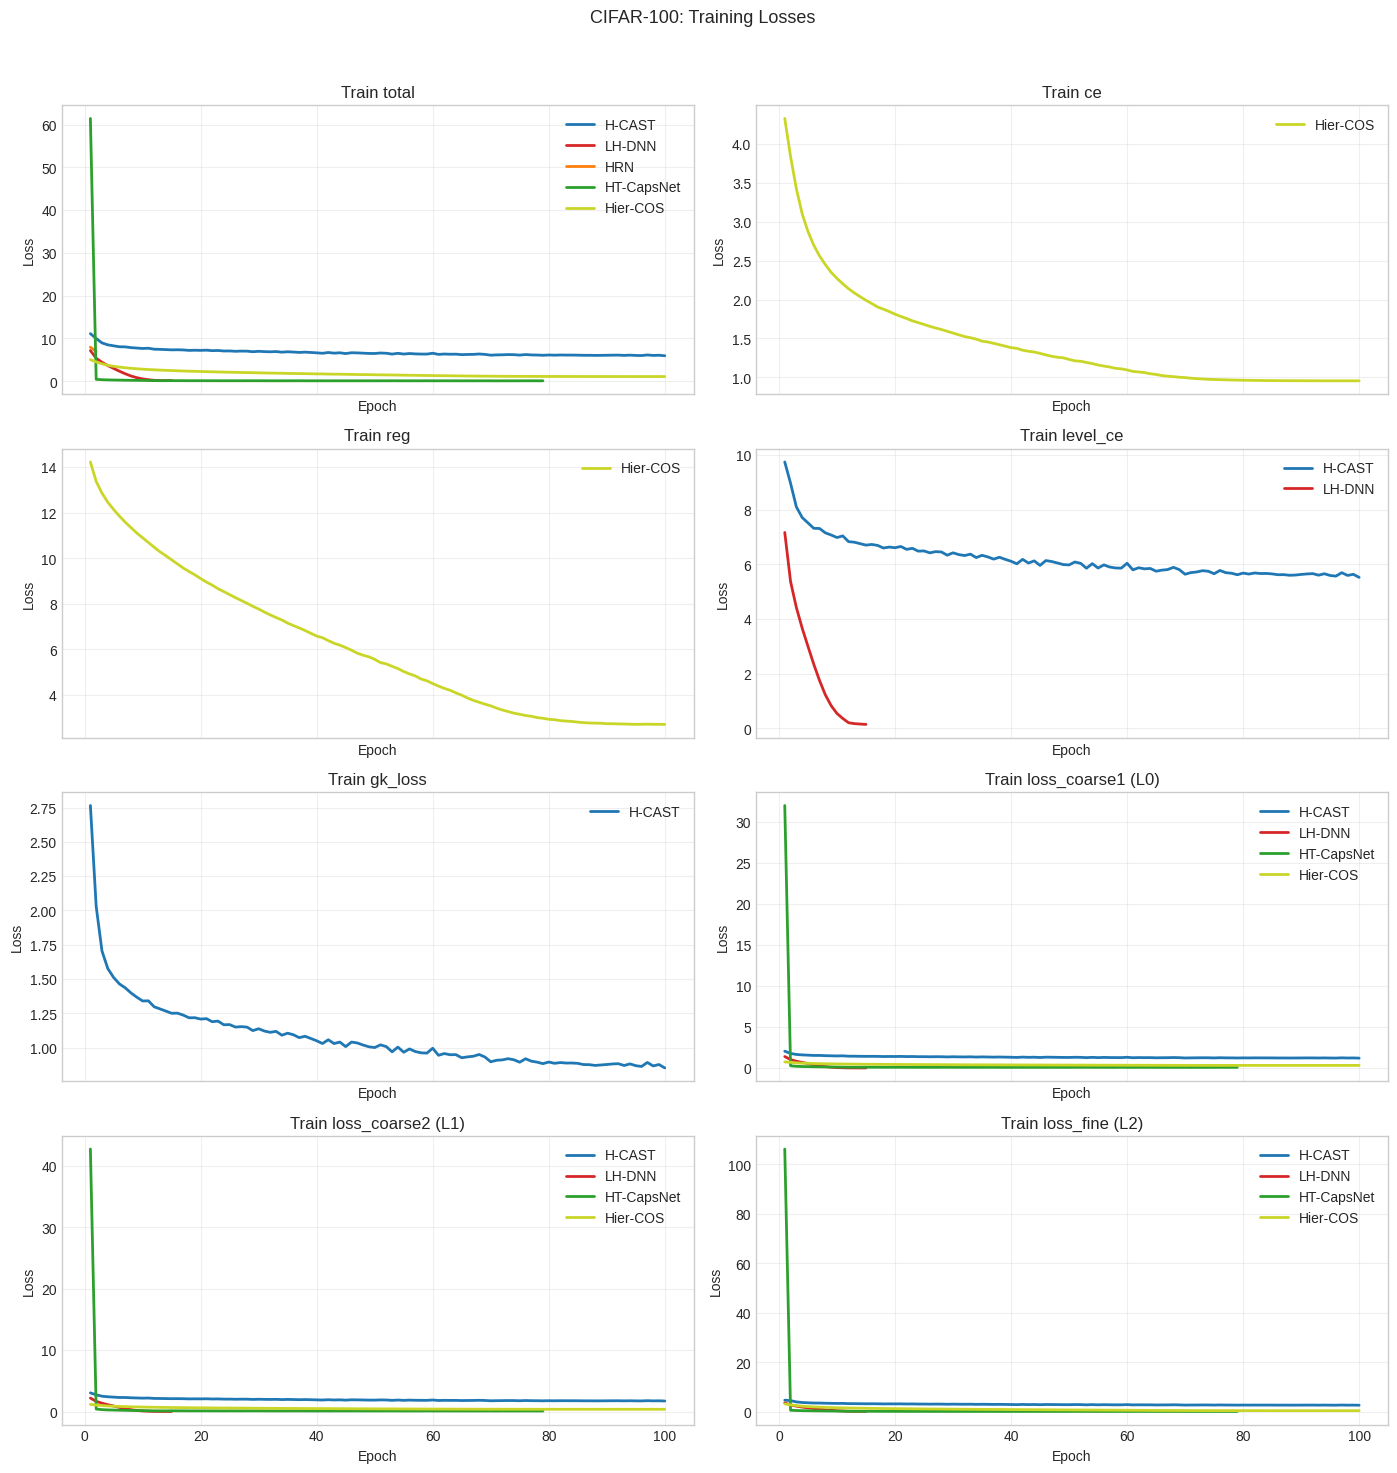

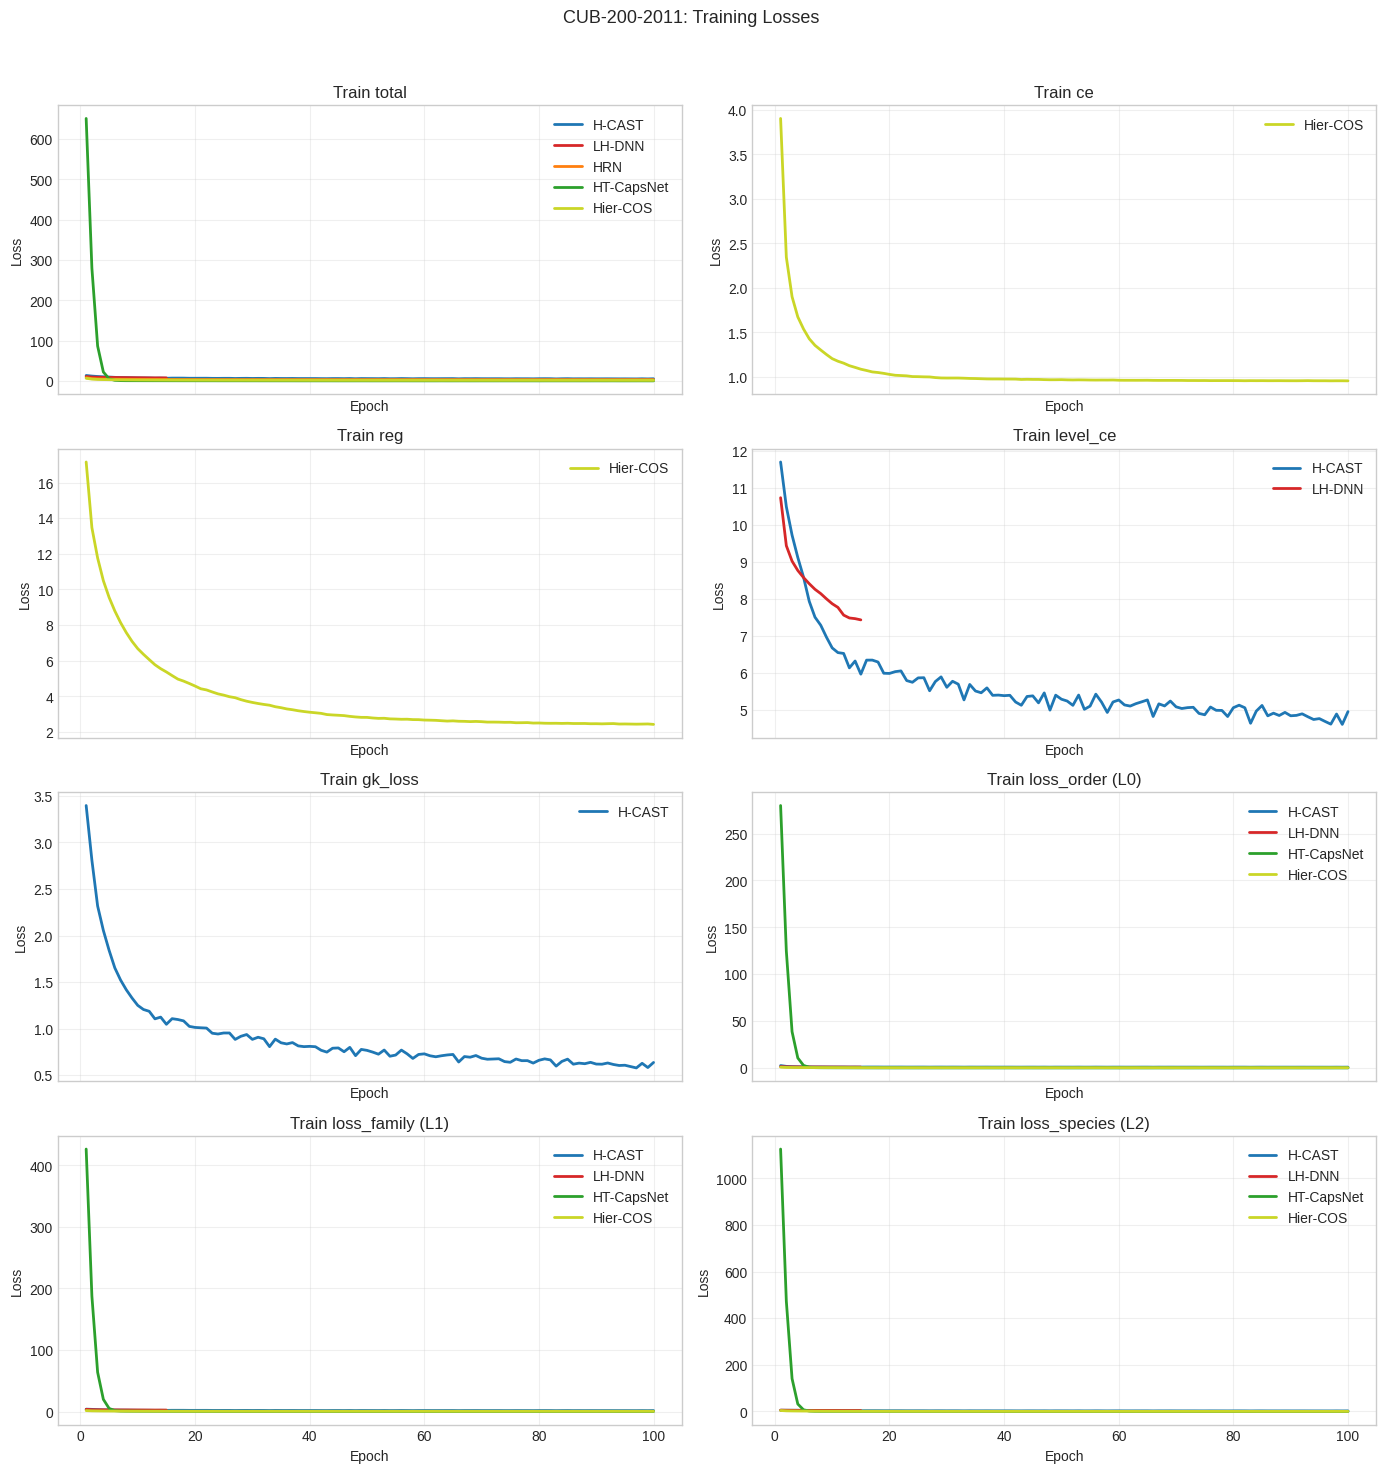

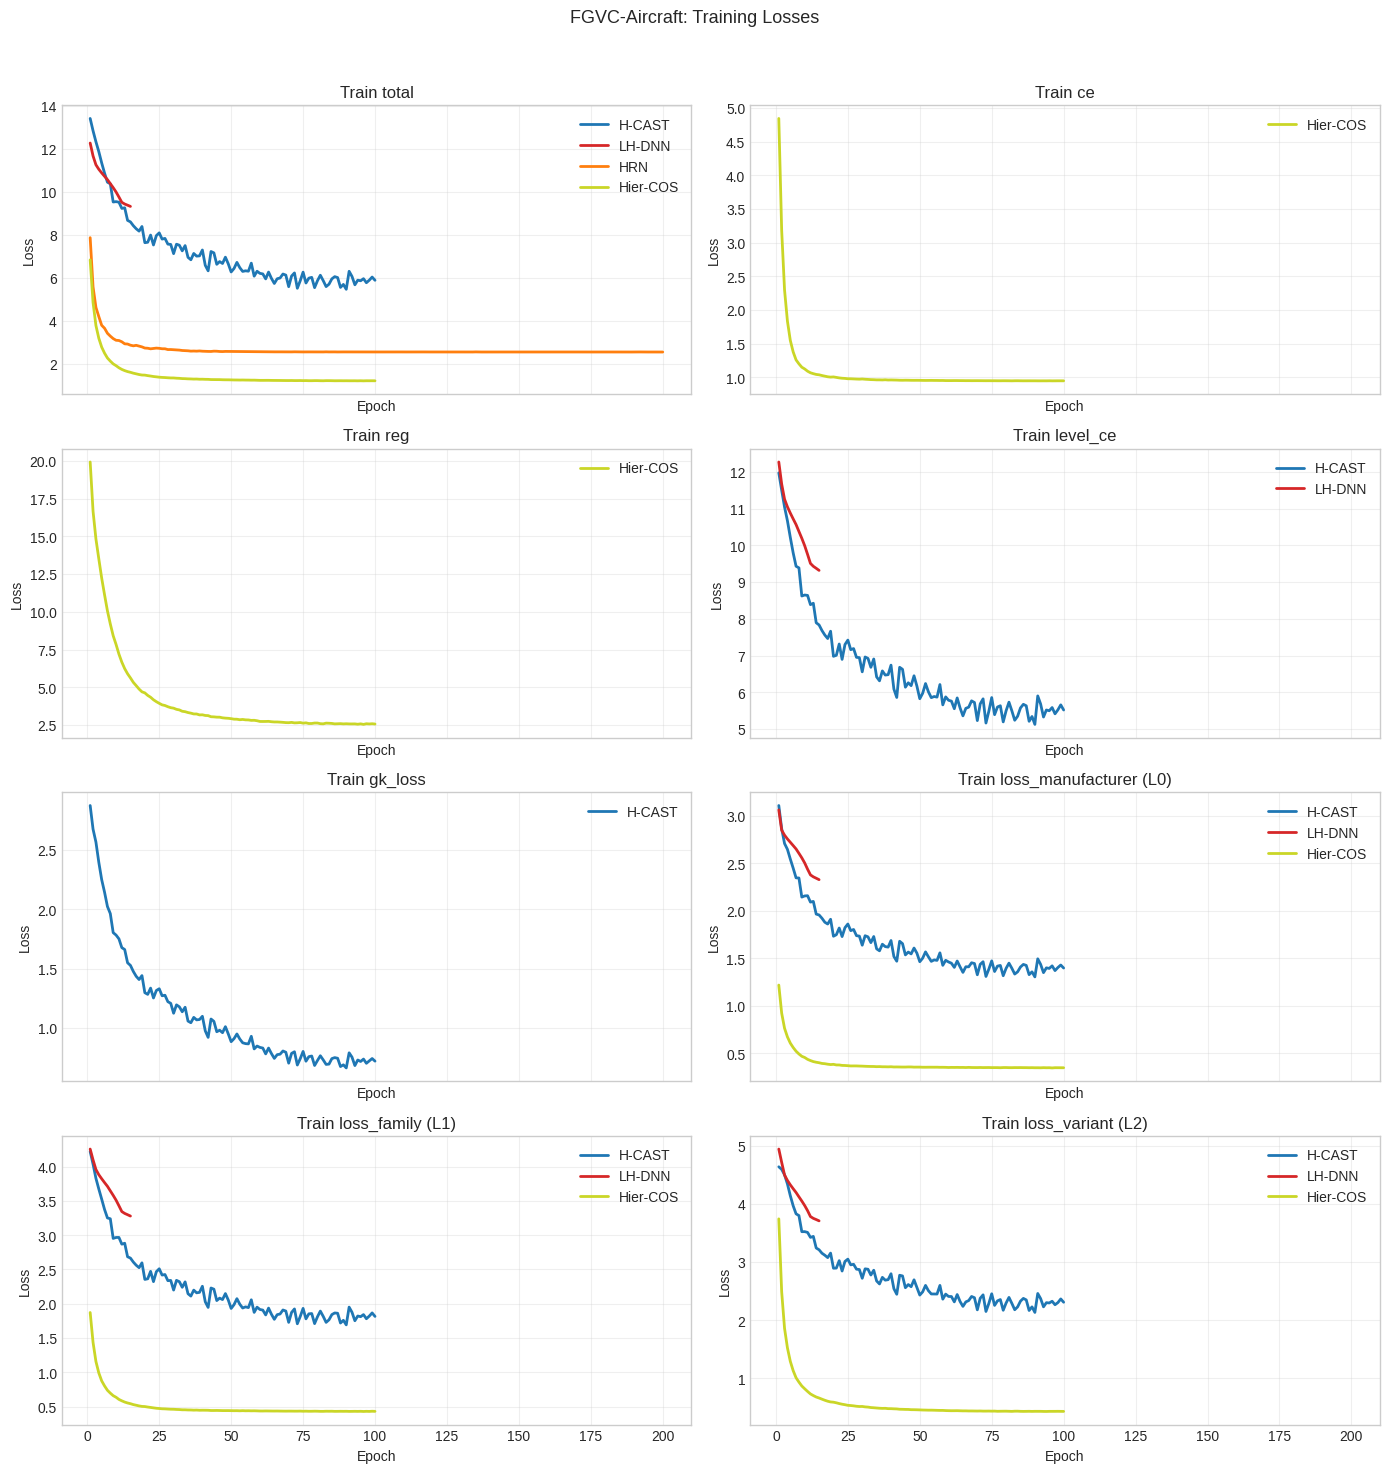

In [5]:
analysis.plot_training_losses_per_dataset()

## Per-Run Per-Level Training Losses (Per Dataset)

Each chart corresponds to one selected model/dataset run and shows every available `loss_level_*` series. These curves help localize whether optimization differences concentrate at coarse, middle, or fine levels.

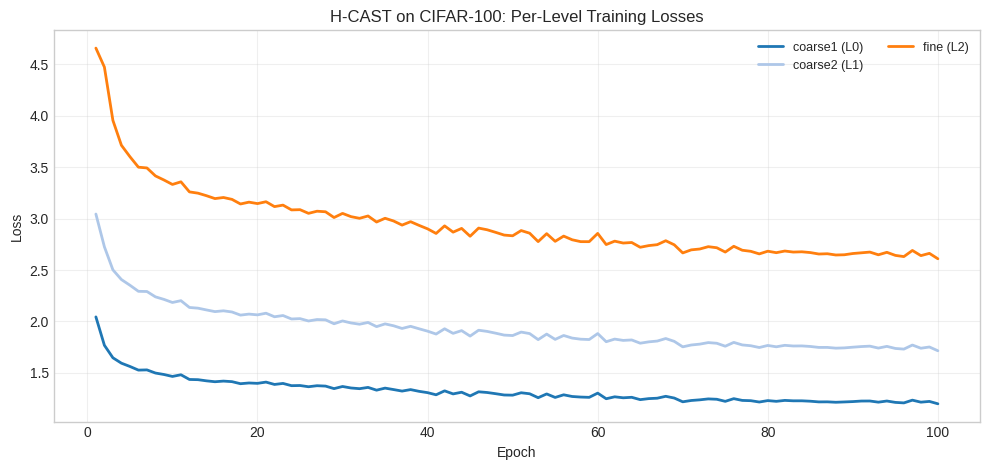

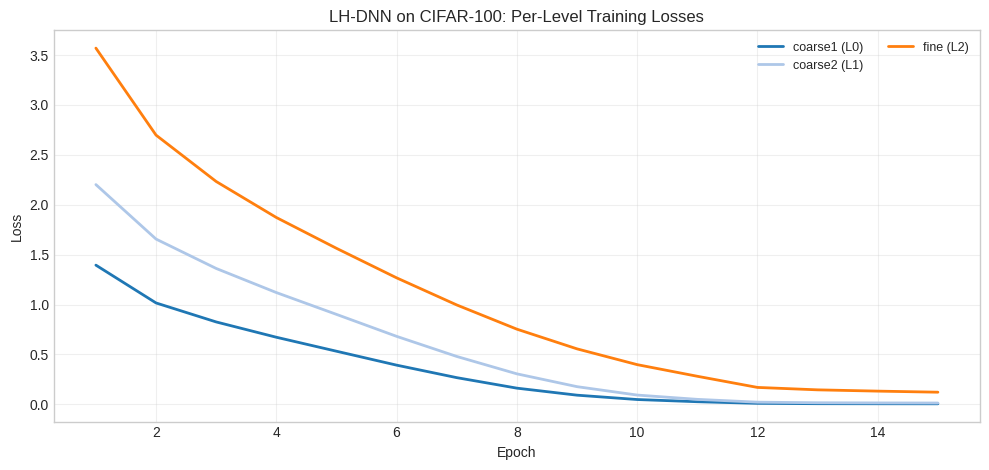

No per-level train losses for HRN on CIFAR-100


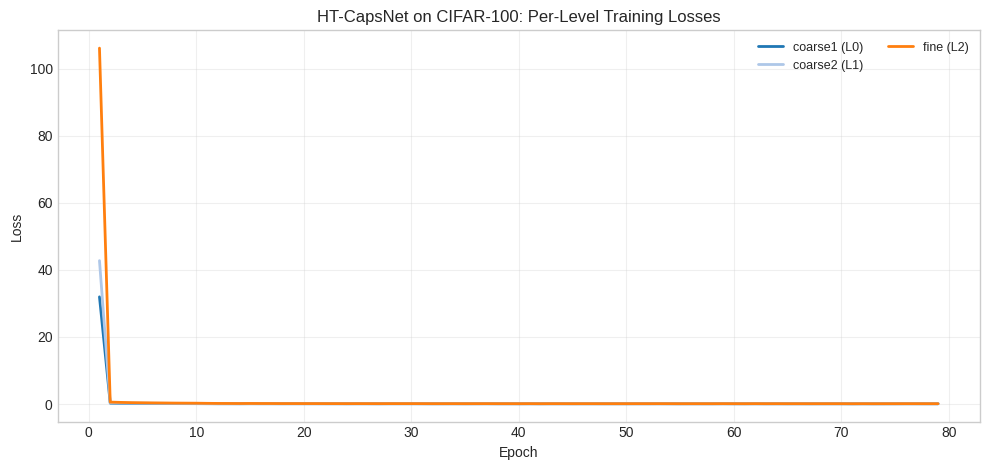

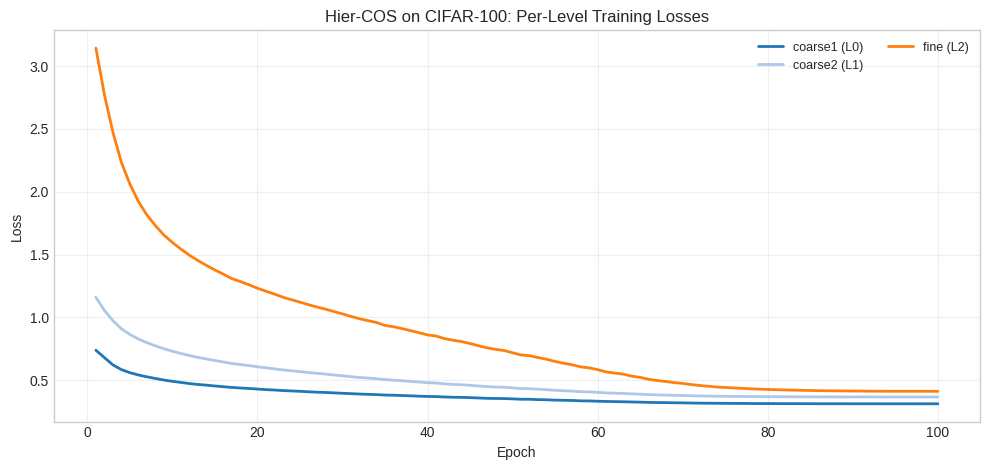

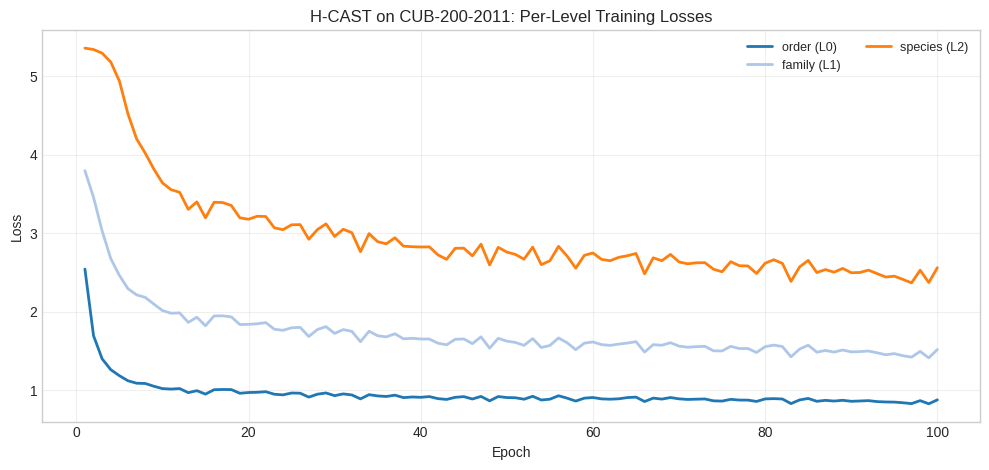

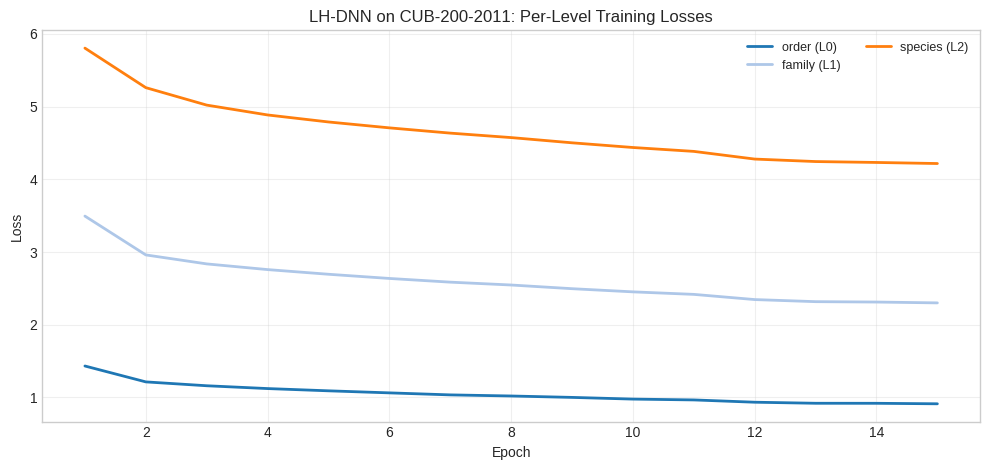

No per-level train losses for HRN on CUB-200-2011


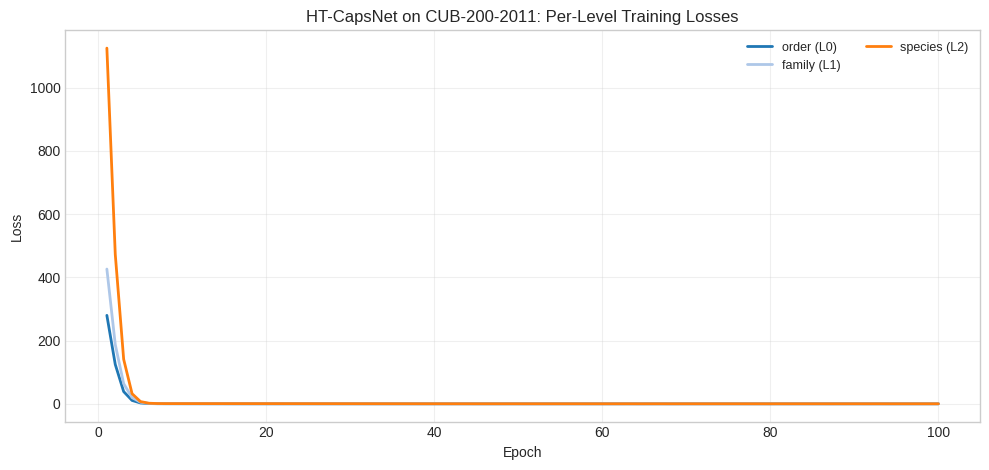

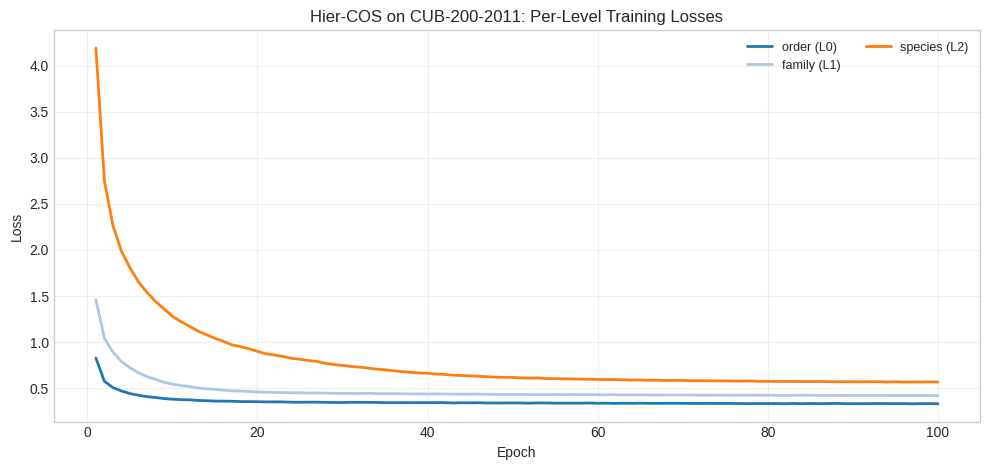

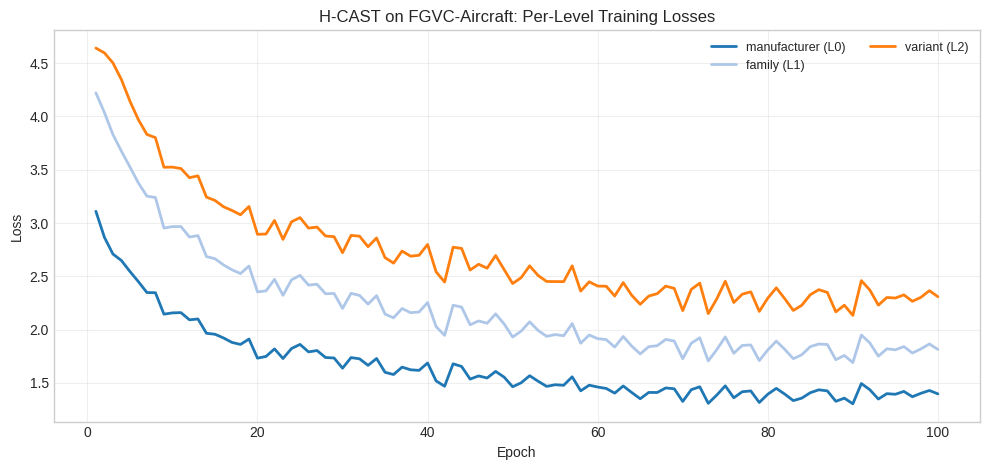

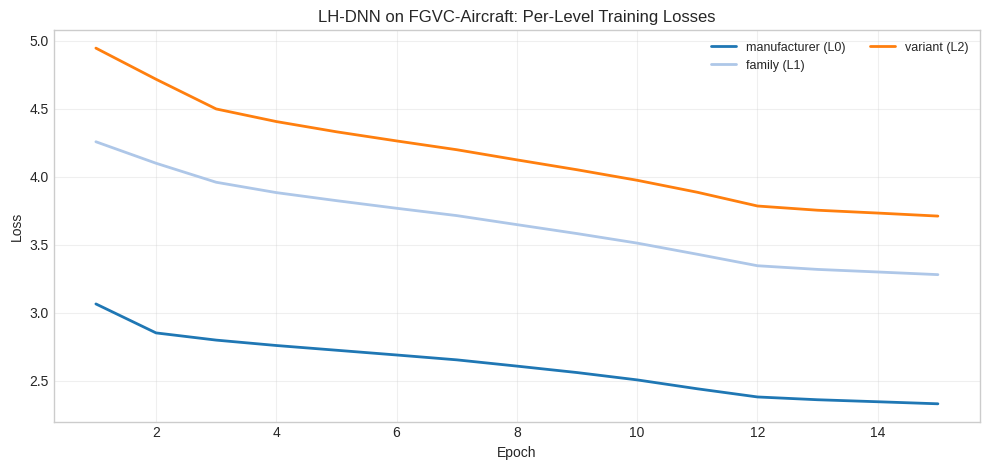

No per-level train losses for HRN on FGVC-Aircraft


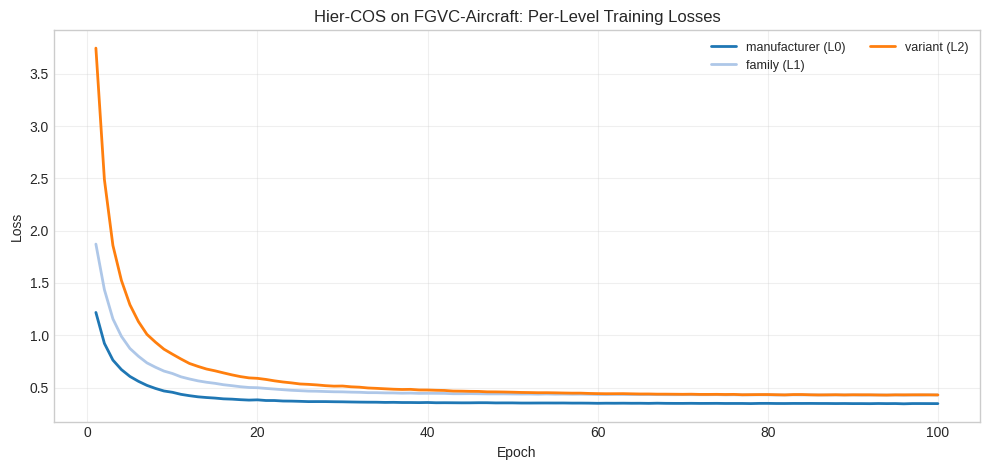

In [6]:
analysis.plot_per_run_per_level_training_losses()

## Per-Level Validation Accuracy (Top-Down and Independent)

Solid versus dashed lines of the same color isolate the decoding effect for one model. Across colors, compare models only at the same hierarchy level and with the same decoding mode.

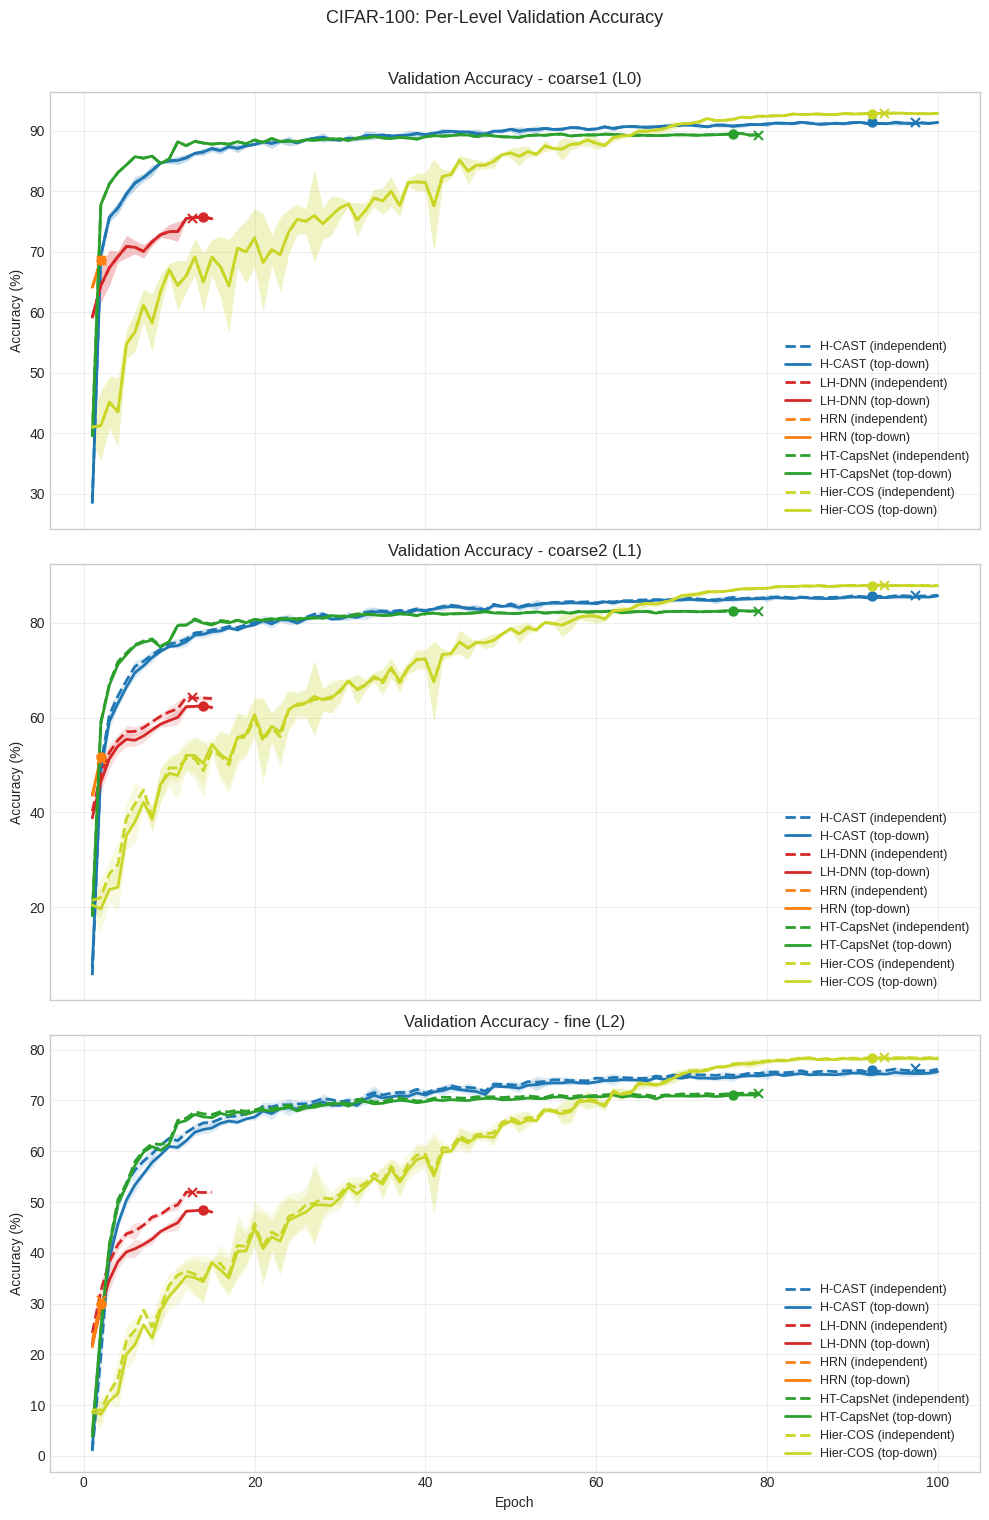

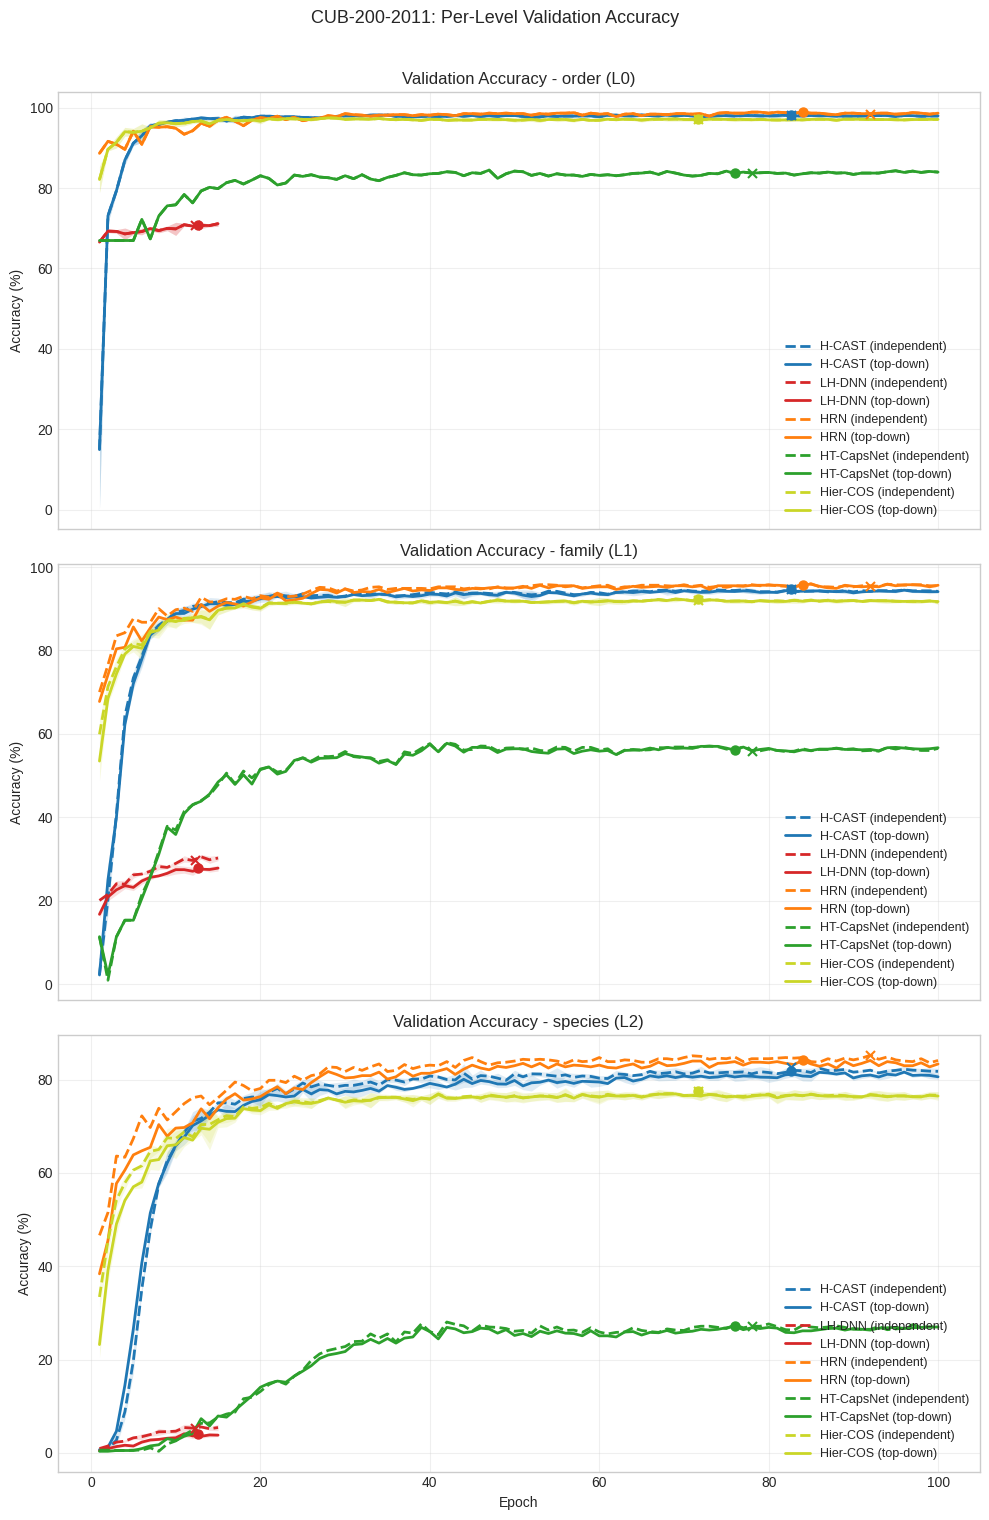

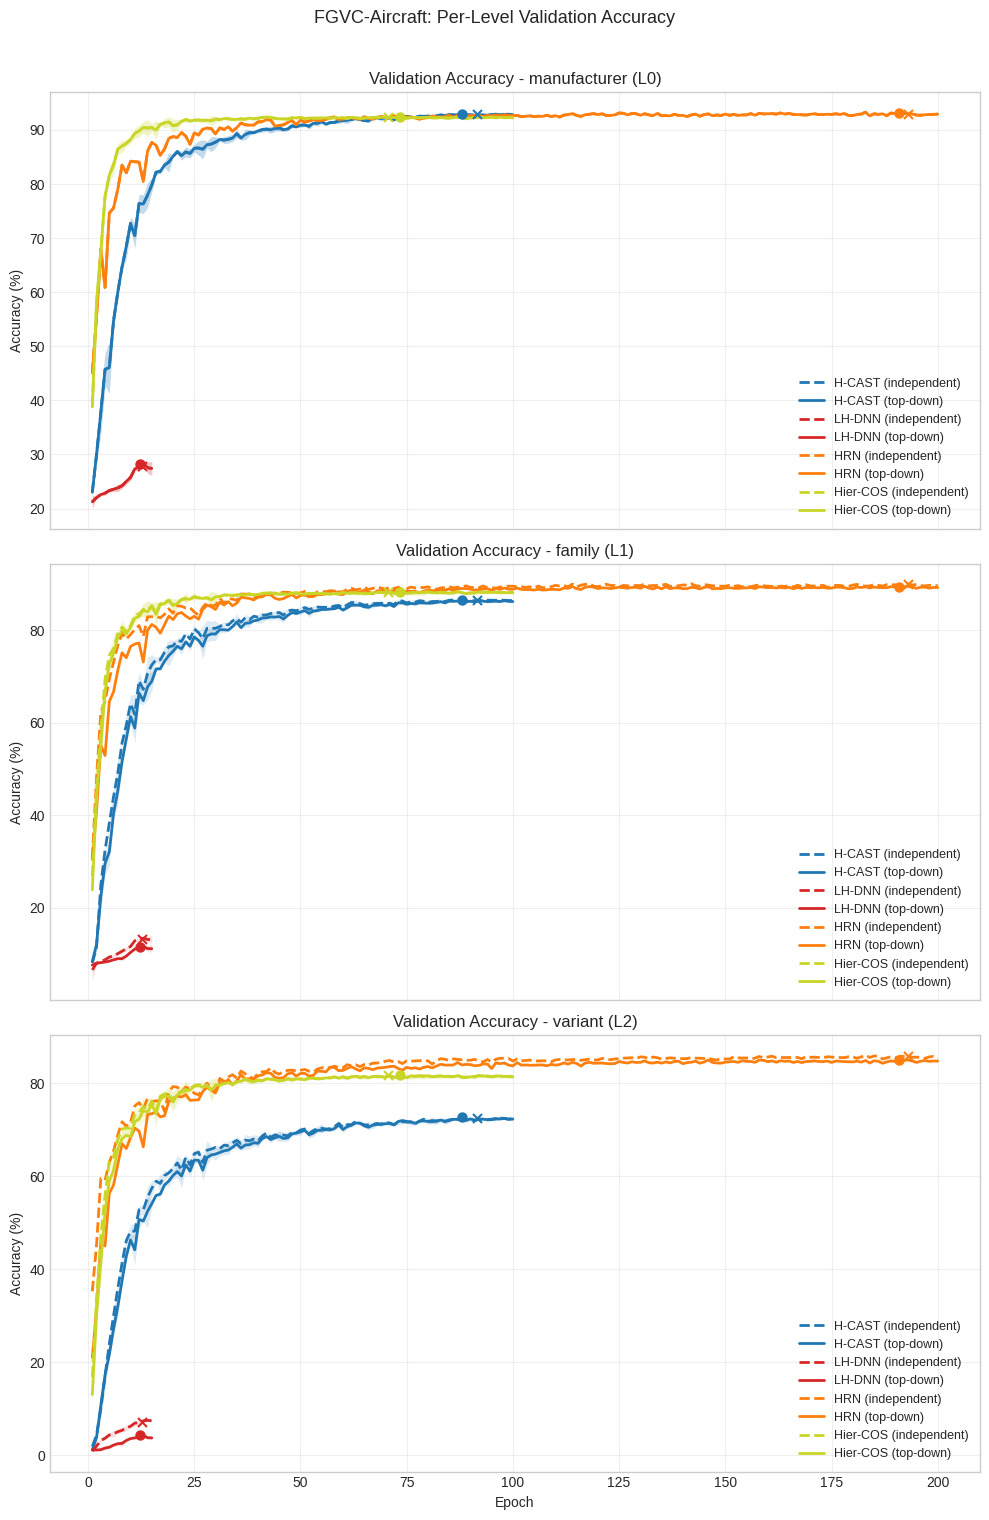

In [7]:
analysis.plot_per_level_validation_accuracy()

## Final Test Comparison Tables (Per Dataset)

H-CAST is listed first and is therefore the delta baseline in each dataset table. Independent rows use the independent-selected checkpoint and top-down rows use the top-down-selected checkpoint. Goal arrows indicate metric direction; deltas between percentage metrics are percentage points.

In [8]:
analysis.show_final_test_tables()

### Dataset: `CIFAR-100`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=1) | HT-CapsNet (n=1) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 92.3 ± 10.0/97.3 ± 2.3 | 14.0 ± 0.0/12.7 ± 1.2 | n/a/n/a | n/a/n/a | 92.3 ± 7.0/93.7 ± 5.0 |
| FPA independent ↑ | <u>73.48% ± 0.19%</u> | 46.14% ± 0.60% (-27.34 pp) | n/a | n/a | **77.52% ± 0.16% (+4.04 pp)** |
| FPA top-down ↑ | <u>75.01% ± 0.18%</u> | 48.20% ± 0.32% (-26.81 pp) | n/a | n/a | **77.74% ± 0.14% (+2.73 pp)** |
| wAP independent ↑ | <u>78.31% ± 0.14%</u> | 55.00% ± 0.48% (-23.32 pp) | n/a | n/a | **80.07% ± 0.20% (+1.75 pp)** |
| wAP top-down ↑ | <u>77.54% ± 0.17%</u> | 51.97% ± 0.32% (-25.57 pp) | n/a | n/a | **80.00% ± 0.13% (+2.46 pp)** |
| TICE independent ↓ | <u>7.61% ± 0.29%</u> | 17.51% ± 0.47% (+9.90 pp) | n/a | n/a | **1.04% ± 0.04% (-6.57 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | n/a | n/a | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.511 ± 0.008</u> | 1.189 ± 0.016 (+0.678) | n/a | n/a | **0.444 ± 0.003 (-0.067)** |
| AHD top-down ↓ | <u>0.493 ± 0.006</u> | 1.154 ± 0.009 (+0.661) | n/a | n/a | **0.441 ± 0.003 (-0.052)** |
| Acc independent coarse1 (L0) ↑ | <u>90.82% ± 0.32%</u> | 74.63% ± 0.47% (-16.19 pp) | n/a | n/a | **91.35% ± 0.06% (+0.53 pp)** |
| Acc top-down coarse1 (L0) ↑ | <u>90.74% ± 0.25%</u> | 74.55% ± 0.27% (-16.19 pp) | n/a | n/a | **91.33% ± 0.09% (+0.59 pp)** |
| Acc independent coarse2 (L1) ↑ | <u>85.20% ± 0.39%</u> | 63.32% ± 0.52% (-21.89 pp) | n/a | n/a | **86.87% ± 0.21% (+1.66 pp)** |
| Acc top-down coarse2 (L1) ↑ | <u>84.92% ± 0.33%</u> | 61.81% ± 0.41% (-23.11 pp) | n/a | n/a | **86.80% ± 0.17% (+1.88 pp)** |
| Acc independent fine (L2) ↑ | <u>75.94% ± 0.20%</u> | 51.76% ± 0.50% (-24.17 pp) | n/a | n/a | **77.80% ± 0.21% (+1.87 pp)** |
| Acc top-down fine (L2) ↑ | <u>75.01% ± 0.18%</u> | 48.20% ± 0.32% (-26.81 pp) | n/a | n/a | **77.74% ± 0.14% (+2.73 pp)** |

### Dataset: `CUB-200-2011`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=1) | HT-CapsNet (n=1) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 82.7 ± 14.0/82.7 ± 14.0 | 12.7 ± 2.1/12.3 ± 2.3 | 84/92 | n/a/n/a | 71.7 ± 16.3/71.7 ± 16.3 |
| FPA independent ↑ | <u>81.27% ± 0.33%</u> | 2.33% ± 0.23% (-78.94 pp) | **82.67% (+1.40 pp)** | n/a | 76.15% ± 0.42% (-5.12 pp) |
| FPA top-down ↑ | <u>82.68% ± 0.15%</u> | 3.66% ± 0.31% (-79.02 pp) | **84.31% (+1.62 pp)** | 26.30% (-56.38 pp) | 76.21% ± 0.47% (-6.47 pp) |
| wAP independent ↑ | <u>85.59% ± 0.13%</u> | 12.64% ± 0.61% (-72.95 pp) | **86.95% (+1.36 pp)** | n/a | 79.58% ± 0.34% (-6.01 pp) |
| wAP top-down ↑ | <u>85.26% ± 0.12%</u> | 10.99% ± 0.24% (-74.27 pp) | **86.62% (+1.36 pp)** | 33.89% (-51.37 pp) | 79.44% ± 0.40% (-5.82 pp) |
| TICE independent ↓ | 5.24% ± 0.41% | 63.05% ± 1.97% (+57.82 pp) | <u>4.83% (-0.40 pp)</u> | n/a | **0.60% ± 0.19% (-4.64 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.262 ± 0.002</u> | 1.996 ± 0.015 (+1.734) | **0.247 (-0.015)** | n/a | 0.366 ± 0.006 (+0.104) |
| AHD top-down ↓ | <u>0.245 ± 0.001</u> | 1.960 ± 0.001 (+1.715) | **0.224 (-0.021)** | 2.660 (+2.414) | 0.365 ± 0.007 (+0.120) |
| Acc independent order (L0) ↑ | <u>98.49% ± 0.14%</u> | 71.30% ± 0.54% (-27.19 pp) | **98.60% (+0.11 pp)** | n/a | 96.85% ± 0.11% (-1.65 pp) |
| Acc top-down order (L0) ↑ | <u>98.49% ± 0.14%</u> | 71.44% ± 0.30% (-27.06 pp) | **98.60% (+0.11 pp)** | 84.10% (-14.39 pp) | 96.85% ± 0.11% (-1.65 pp) |
| Acc independent family (L1) ↑ | <u>94.36% ± 0.11%</u> | 30.62% ± 1.09% (-63.73 pp) | **94.54% (+0.19 pp)** | n/a | 90.51% ± 0.13% (-3.84 pp) |
| Acc top-down family (L1) ↑ | <u>94.29% ± 0.06%</u> | 28.87% ± 0.13% (-65.42 pp) | **94.68% (+0.39 pp)** | 56.61% (-37.68 pp) | 90.45% ± 0.17% (-3.84 pp) |
| Acc independent species (L2) ↑ | <u>83.09% ± 0.16%</u> | 5.41% ± 0.55% (-77.68 pp) | **84.75% (+1.67 pp)** | n/a | 76.38% ± 0.41% (-6.70 pp) |
| Acc top-down species (L2) ↑ | <u>82.68% ± 0.15%</u> | 3.66% ± 0.31% (-79.02 pp) | **84.31% (+1.62 pp)** | 26.30% (-56.38 pp) | 76.21% ± 0.47% (-6.47 pp) |

### Dataset: `FGVC-Aircraft`
Baseline run: **H-CAST**

| Metric | H-CAST (n=3) | LH-DNN (n=3) | HRN (n=1) | Hier-COS (n=3) |
|---|---:|---:|---:|---:|
| Best epoch (TD/Ind) | 88.0 ± 7.2/91.7 ± 5.5 | 12.3 ± 1.2/12.7 ± 1.5 | 191/193 | 73.3 ± 4.0/70.7 ± 11.0 |
| FPA independent ↑ | 70.73% ± 1.04% | 1.96% ± 0.23% (-68.77 pp) | **84.54% (+13.82 pp)** | <u>81.40% ± 0.52% (+10.67 pp)</u> |
| FPA top-down ↑ | 73.47% ± 0.92% | 3.85% ± 0.38% (-69.62 pp) | **85.92% (+12.46 pp)** | <u>81.74% ± 0.43% (+8.27 pp)</u> |
| wAP independent ↑ | 81.09% ± 0.61% | 12.26% ± 0.20% (-68.83 pp) | **89.37% (+8.27 pp)** | <u>85.44% ± 0.37% (+4.35 pp)</u> |
| wAP top-down ↑ | 81.30% ± 0.67% | 10.02% ± 0.44% (-71.29 pp) | **88.78% (+7.48 pp)** | <u>85.60% ± 0.28% (+4.29 pp)</u> |
| TICE independent ↓ | 9.09% ± 0.10% | 80.71% ± 1.31% (+71.62 pp) | <u>6.80% (-2.29 pp)</u> | **0.78% ± 0.13% (-8.31 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% ± 0.00% (+0.00 pp)** | **0.00% (+0.00 pp)** | **0.00% ± 0.00% (+0.00 pp)** |
| AHD independent ↓ | <u>0.492 ± 0.013</u> | 2.615 ± 0.004 (+2.123) | 0.646 (+0.154) | **0.384 ± 0.008 (-0.108)** |
| AHD top-down ↓ | <u>0.459 ± 0.016</u> | 2.576 ± 0.013 (+2.117) | 0.592 (+0.133) | **0.378 ± 0.007 (-0.081)** |
| Acc independent manufacturer (L0) ↑ | <u>93.31% ± 0.12%</u> | 26.65% ± 0.49% (-66.66 pp) | **93.57% (+0.26 pp)** | 92.22% ± 0.05% (-1.09 pp) |
| Acc top-down manufacturer (L0) ↑ | <u>93.30% ± 0.18%</u> | 27.02% ± 0.49% (-66.28 pp) | **93.72% (+0.42 pp)** | 92.20% ± 0.17% (-1.10 pp) |
| Acc independent family (L1) ↑ | 87.57% ± 0.51% | 13.42% ± 0.17% (-74.15 pp) | **91.20% (+3.63 pp)** | <u>88.10% ± 0.33% (+0.53 pp)</u> |
| Acc top-down family (L1) ↑ | 87.36% ± 0.65% | 11.54% ± 0.57% (-75.82 pp) | **90.75% (+3.39 pp)** | <u>88.28% ± 0.18% (+0.92 pp)</u> |
| Acc independent variant (L2) ↑ | 72.90% ± 1.05% | 7.13% ± 0.37% (-65.77 pp) | **86.82% (+13.93 pp)** | <u>81.55% ± 0.52% (+8.65 pp)</u> |
| Acc top-down variant (L2) ↑ | 73.47% ± 0.92% | 3.85% ± 0.38% (-69.62 pp) | **85.92% (+12.46 pp)** | <u>81.74% ± 0.43% (+8.27 pp)</u> |

Interpretation note:

- Compare only rows produced from the same decoding mode.
- Seed counts may differ between models; treat single-seed results as less stable than three-seed aggregates.
- Missing or incomplete experiment directories are reported when the analysis object is created and are excluded from plots and tables.
- HRN on CIFAR-100 and Hier-COS on CUB are local extrapolations rather than paper-aligned settings.